# Implementación de Data Augmentation  y Transfer Learning en imagenes


### Importaciones y configuración del entorno



In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications
import matplotlib.pyplot as plt
import numpy as np
import warnings

# Ocultar advertencias innecesarias de inicialización
warnings.filterwarnings('ignore')

# Configurar semillas para asegurar la reproducibilidad de los experimentos
tf.random.set_seed(42)
np.random.seed(42)


### Cargamos el dataset CIFAR-10 y preparamos los datos.

In [ ]:
print("\n--- Cargando el dataset CIFAR-10 ---")
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()

# Nombres de las clases para las etiquetas de CIFAR-10
class_names = ['avión', 'automóvil', 'pájaro', 'gato', 'ciervo', 'perro', 'rana', 'caballo', 'barco', 'camión']

# Normalización de los datos (escalado de píxeles al rango [0, 1])
train_images_norm = train_images.astype('float32') / 255.0
test_images_norm = test_images.astype('float32') / 255.0

print(f"Dimensiones de entrenamiento: {train_images_norm.shape}")
print(f"Dimensiones de prueba/validación: {test_images_norm.shape}")
print(" Dataset cargado, estructurado y normalizado.")


--- Cargando el dataset CIFAR-10 ---
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 373s 2us/step
Dimensiones de entrenamiento: (50000, 32, 32, 3)
Dimensiones de prueba/validación: (10000, 32, 32, 3)
 Dataset cargado, estructurado y normalizado.


## Implementación de Data Augmentation
Definimos las técnicas solicitadas  y comparamos dos modelos.
- Rotación.
- Traslación
- Flip.
- Zoom.



In [ ]:
# Definición de técnicas
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.1),
  layers.RandomZoom(0.1),
  layers.RandomTranslation(0.1, 0.1)
])



### VISUALIZACIÓN

Visualización de imagen original vs transformada

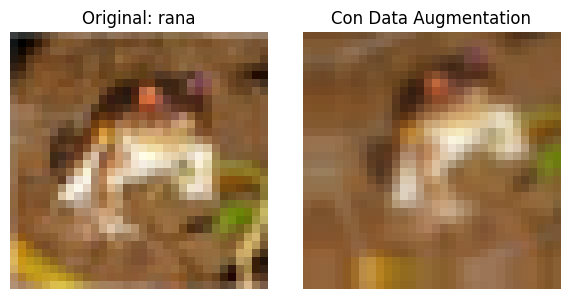

In [ ]:
# Visualización de imagen original vs transformada
plt.figure(figsize=(6, 3))

# Imagen Original
plt.subplot(1, 2, 1)
plt.imshow(train_images_norm[0])
plt.title(f"Original: {class_names[train_labels[0][0]]}")
plt.axis("off")

# Imagen Transformada (Expandimos dimensión para simular un batch de tamaño 1)
plt.subplot(1, 2, 2)
augmented_img = data_augmentation(tf.expand_dims(train_images_norm[0], 0), training=True)
plt.imshow(augmented_img[0])
plt.title("Con Data Augmentation")
plt.axis("off")

plt.tight_layout()
plt.show()

## Entrenamiento y Evaluación del Impacto

Entrenamos un modelo Base (sin aumentos) y un modelo Aumentado para evaluar el impacto.

###  ENTRENAMIENTO: Modelo Base ( SIN Data Augmentation

In [ ]:

# Modelo SIN Data Augmentation
model_base = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
], name="Modelo_Base")

model_base.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Entrenamiento por 10 épocas utilizando un tamaño de lote estándar (batch_size=64)
history_base = model_base.fit(
    train_images_norm, train_labels,
    epochs=10,
    batch_size=64,
    validation_data=(test_images_norm, test_labels),
    verbose=1
)


Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 60s 72ms/step - accuracy: 0.4109 - loss: 1.6210 - val_accuracy: 0.5112 - val_loss: 1.3726
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 45s 57ms/step - accuracy: 0.5367 - loss: 1.3001 - val_accuracy: 0.5670 - val_loss: 1.2264
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 45s 58ms/step - accuracy: 0.5797 - loss: 1.1893 - val_accuracy: 0.5901 - val_loss: 1.1625
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 43s 55ms/step - accuracy: 0.6075 - loss: 1.1151 - val_accuracy: 0.6055 - val_loss: 1.1207
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 43s 55ms/step - accuracy: 0.6298 - loss: 1.0555 - val_accuracy: 0.6168 - val_loss: 1.0897
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 79s 52ms/step - accuracy: 0.6483 - loss: 1.0061 - val_accuracy: 0.6260 - val_loss: 1.0670
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 39s 50ms/step - accuracy: 0.6620 - loss: 0.9655 - val_accuracy: 0.6352 - val_loss: 1.0518
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 51ms/step - accuracy: 0.6757 - loss: 0.9298 - 

##  ENTRENAMIENTO: Modelo CON Data Augmentation

In [ ]:
# Modelo CON Data Augmentation
model_with_da = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    data_augmentation,    # Inserción de la capa de transformaciones aleatorias
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
], name="Modelo_Con_Augmentation")

model_with_da.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_da = model_with_da.fit(
    train_images_norm, train_labels,
    epochs=10,
    batch_size=64,
    validation_data=(test_images_norm, test_labels),
    verbose=1
)


Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 59s 73ms/step - accuracy: 0.3890 - loss: 1.7035 - val_accuracy: 0.4571 - val_loss: 1.5511
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 73ms/step - accuracy: 0.4637 - loss: 1.4997 - val_accuracy: 0.5116 - val_loss: 1.3903
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 81s 71ms/step - accuracy: 0.4873 - loss: 1.4333 - val_accuracy: 0.5343 - val_loss: 1.3328
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 57s 73ms/step - accuracy: 0.5014 - loss: 1.3946 - val_accuracy: 0.5468 - val_loss: 1.3188
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 75ms/step - accuracy: 0.5109 - loss: 1.3670 - val_accuracy: 0.5469 - val_loss: 1.3207
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 81s 73ms/step - accuracy: 0.5186 - loss: 1.3433 - val_accuracy: 0.5477 - val_loss: 1.3081
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 59s 75ms/step - accuracy: 0.5286 - loss: 1.3241 - val_accuracy: 0.5637 - val_loss: 1.2711
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 68s 87ms/step - accuracy: 0.5296 - loss: 1.3131 - 

## ENTRENAMIENTO: TRANSFER LEARNING (MOBILENETV2)



In [ ]:
# Configurando e Implementando Transfer Learning

# Entrada de red con reescalado (Upsampling) a 96x96 para evitar el colapso de MobileNetV2
inputs_tl = layers.Input(shape=(32, 32, 3))
resize_layer = layers.Resizing(96, 96)(inputs_tl)

# Preprocesamiento específico que requiere internamente MobileNetV2 (escalado a rangos nativos)
preprocessed_inputs = applications.mobilenet_v2.preprocess_input(resize_layer * 255.0)

# Carga de la arquitectura preentrenada con ImageNet (Excluyendo la cabeza superior de 1000 clases)
base_model = applications.MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False,
    weights='imagenet'
)

# Congelar las capas del modelo base
base_model.trainable = False

# Construcción y ajuste de la nueva cabeza clasificadora adaptada a las 10 clases de CIFAR-10
x = base_model(preprocessed_inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)                  # Reducción global de dimensiones
x = layers.Dropout(0.2)(x)                             # Regularización adicional para estabilidad
outputs_tl = layers.Dense(10, activation='softmax')(x)  # Capa de salida lineal final

model_tl = models.Model(inputs_tl, outputs_tl, name="Modelo_Transfer_Learning")

model_tl.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Entrenamiento
history_tl = model_tl.fit(
    train_images_norm, train_labels,
    epochs=10,
    batch_size=64,
    validation_data=(test_images_norm, test_labels),
    verbose=1
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 428s 538ms/step - accuracy: 0.7896 - loss: 0.6275 - val_accuracy: 0.8471 - val_loss: 0.4348
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 436s 531ms/step - accuracy: 0.8464 - loss: 0.4522 - val_accuracy: 0.8511 - val_loss: 0.4188
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 444s 534ms/step - accuracy: 0.8550 - loss: 0.4237 - val_accuracy: 0.8504 - val_loss: 0.4221
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 407s 520ms/step - accuracy: 0.8593 - loss: 0.4107 - val_accuracy: 0.8524 - val_loss: 0.4203
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 453s 534ms/step - accuracy: 0.8599 - loss: 0.4026 - val_accuracy: 0.8508 - val_loss: 0.4211
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 460s 557ms/step - accuracy: 0.8624 - loss: 0.3969 - val_accuracy: 0.8538 - val_loss: 0.4160
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 420s 529ms/step - accuracy: 0.8637 - loss: 0.3946 - val_accuracy: 0.8535 - val_loss: 0.4221
Epoch 8/10
782/782 ━━━━━━━━

## Evaluación de Resultados

Gráficas para comparar el desempeño de los escenarios.


 Gráficas Comparativas de Rendimiento 


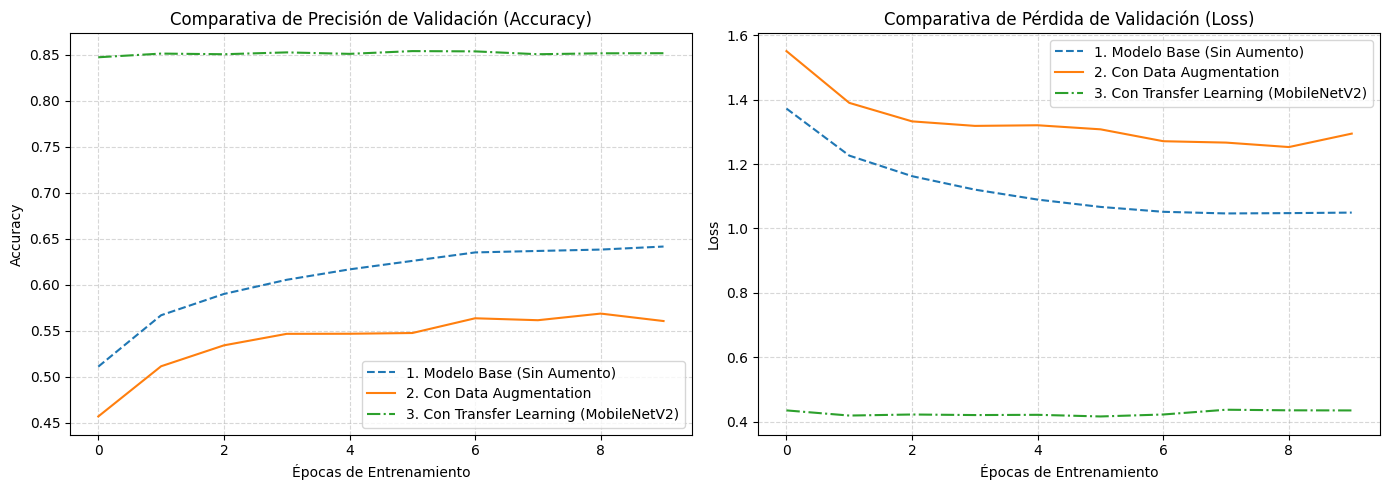


 RESUMEN FINAL DE MÉTRICAS OBTENIDAS EN LA ÉPOCA 10
 Modelo Base             -> Val Accuracy: 0.6416 | Val Loss: 1.0494
 Modelo con Augmentation -> Val Accuracy: 0.5607 | Val Loss: 1.2948
 Modelo Transfer Learning -> Val Accuracy: 0.8515 | Val Loss: 0.4347


In [12]:

print("\n Gráficas Comparativas de Rendimiento ")

plt.figure(figsize=(14, 5))

# 1. Gráfica Comparativa de Precisión (Accuracy de Validación)
plt.subplot(1, 2, 1)
plt.plot(history_base.history['val_accuracy'], label='1. Modelo Base (Sin Aumento)', linestyle='--')
plt.plot(history_da.history['val_accuracy'], label='2. Con Data Augmentation', linestyle='-')
plt.plot(history_tl.history['val_accuracy'], label='3. Con Transfer Learning (MobileNetV2)', linestyle='-.')
plt.title('Comparativa de Precisión de Validación (Accuracy)')
plt.xlabel('Épocas de Entrenamiento')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# 2. Gráfica Comparativa de Pérdida (Loss de Validación)
plt.subplot(1, 2, 2)
plt.plot(history_base.history['val_loss'], label='1. Modelo Base (Sin Aumento)', linestyle='--')
plt.plot(history_da.history['val_loss'], label='2. Con Data Augmentation', linestyle='-')
plt.plot(history_tl.history['val_loss'], label='3. Con Transfer Learning (MobileNetV2)', linestyle='-.')
plt.title('Comparativa de Pérdida de Validación (Loss)')
plt.xlabel('Épocas de Entrenamiento')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("\n RESUMEN FINAL DE MÉTRICAS OBTENIDAS EN LA ÉPOCA 10")
print(f" Modelo Base             -> Val Accuracy: {history_base.history['val_accuracy'][-1]:.4f} | Val Loss: {history_base.history['val_loss'][-1]:.4f}")
print(f" Modelo con Augmentation -> Val Accuracy: {history_da.history['val_accuracy'][-1]:.4f} | Val Loss: {history_da.history['val_loss'][-1]:.4f}")
print(f" Modelo Transfer Learning -> Val Accuracy: {history_tl.history['val_accuracy'][-1]:.4f} | Val Loss: {history_tl.history['val_loss'][-1]:.4f}")


## Conclusiones

Tras analizar la gráfica comparativa de la precisión de validación, se establecen las siguientes conclusiones:


Análisis del Impacto de cada Técnica en el Desempeño

- Modelo Base (Sin Aumento):Comportamiento:
 Alcanza de forma rápida una precisión aceptable (~64.16%) con un descenso progresivo de la pérdida (1.0494).

    Causa: Al procesar matrices de píxeles estáticas, optimiza sus pesos de forma directa para el conjunto de entrenamiento local. Esto genera una convergencia veloz en las primeras 10 épocas, pero con una alta vulnerabilidad a estancarse en mínimos locales o sobreajustarse si se extiende el entrenamiento.

- Modelo con Data Augmentation:Comportamiento:
 Registra el desempeño numérico más bajo en la ventana analizada (Accuracy: 56.07% / Loss: 1.2948). Además, en las últimas épocas la curva de pérdida de validación muestra una ligera tendencia ascendente.

    Causa: Las transformaciones geométricas continuas (rotación, traslación, zoom) actúan como una fuerte penalización de regularización. A corto plazo (10 épocas), esto dificulta la convergencia del optimizador al alterar los patrones estáticos. Técnicamente, este enfoque requiere un presupuesto sustancialmente mayor de épocas para estabilizar su costo (loss) y superar la precisión del modelo base, aunque teóricamente asegura mayor robustez ante datos externos del mundo real.

- Modelo con Transfer Learning (MobileNetV2):
Comportamiento: Domina de forma absoluta todos los escenarios desde la primera época, alcanzando un desempeño sobresaliente (Accuracy: 85.15% / Loss: 0.4347) con curvas asintóticas perfectas y estables.

    Causa: La integración de la capa de reescalado a 96x96 evitó el colapso espacial de la información. Al congelar los pesos preentrenados en ImageNet, el modelo reutiliza extractores de características macro (formas complejas, bordes y texturas abstractas). La red solo debe computar el ajuste de la cabeza clasificadora final, maximizando la eficiencia computacional y anulando el sobreajuste.
    

Conclusiones Técnicas de la ActividadVentajas, Limitaciones y Casos de Uso:

- Data Augmentation: Incrementa artificialmente la variabilidad del dataset sin costo de captura. Su limitación principal es la ralentización drástica de la convergencia inicial y el incremento del coste de cómputo por época. Es ideal para escenarios con escasez estricta de datos donde se planea realizar entrenamientos masivos a largo plazo.

- Transfer Learning: Es la técnica más eficiente y competitiva. Su ventaja radica en lograr precisiones superiores al 85% en pocas iteraciones empleando arquitecturas optimizadas (MobileNetV2). Su limitación crítica es la dependencia de la resolución de entrada; requiere un preprocesamiento de reescalado (upsampling) obligatorio cuando se trabaja con imágenes nativas pequeñas como las de CIFAR-10 (32x32). Es la estrategia idónea para proyectos comerciales con tiempos de entrega reducidos y hardware limitado.
